In [ ]:
!pip -q install "datasets==3.6.0" "huggingface_hub==0.36.2" torchmetrics tqdm pillow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import hashlib
import json
import math
import platform
import random
import shutil
import time
from dataclasses import dataclass
from io import BytesIO
from pathlib import Path
from typing import Any

import datasets
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from PIL import Image, ImageFile
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, IterableDataset
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Tiny_Weights
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("datasets version:", datasets.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Training ConvNeXt on CPU will be very slow.")

datasets version: 3.6.0
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
SEED = 42


def seed_everything(seed: int = 42) -> None:
    """Set random seeds for more repeatable training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    project_name: str = "document-classifier-rvlcdip"

    backbone: str = "convnext_tiny"
    weights_enum: str = "ConvNeXt_Tiny_Weights.IMAGENET1K_V1"

    num_classes: int = 16
    input_size: int = 224

    batch_size: int = 128
    num_workers: int = 0
    epochs: int = 8

    learning_rate: float = 1e-4
    weight_decay: float = 1e-2

    freeze_policy: str = "partial_unfreeze"
    min_test_top1: float = 0.80

    # Early stopping
    early_stopping_patience: int = 2
    early_stopping_min_delta: float = 0.001

    output_dir: str = "/content/doc_classifier_outputs"
    artifacts_dir: str = "/content/doc_classifier_outputs/artifacts_for_repo"

    # Google Drive checkpoint folder
    drive_checkpoint_dir: str = "/content/drive/MyDrive/doc_classifier_checkpoints"

    # Use True only to test the notebook quickly.
    # For real training, keep it False.
    fast_dev_run: bool = False

    fast_train_samples: int = 2048
    fast_val_samples: int = 512
    fast_test_samples: int = 512


config = TrainConfig()

CLASS_LABELS = [
    "letter",
    "form",
    "email",
    "handwritten",
    "advertisement",
    "scientific_report",
    "scientific_publication",
    "specification",
    "file_folder",
    "news_article",
    "budget",
    "invoice",
    "presentation",
    "questionnaire",
    "resume",
    "memo",
]

label_id_to_name = {idx: name for idx, name in enumerate(CLASS_LABELS)}
label_name_to_id = {name: idx for idx, name in enumerate(CLASS_LABELS)}

Path(config.output_dir).mkdir(parents=True, exist_ok=True)
Path(config.artifacts_dir).mkdir(parents=True, exist_ok=True)

print(config)

TrainConfig(project_name='document-classifier-rvlcdip', backbone='convnext_tiny', weights_enum='ConvNeXt_Tiny_Weights.IMAGENET1K_V1', num_classes=16, input_size=224, batch_size=128, num_workers=0, epochs=8, learning_rate=0.0001, weight_decay=0.01, freeze_policy='partial_unfreeze', min_test_top1=0.8, early_stopping_patience=2, early_stopping_min_delta=0.001, output_dir='/content/doc_classifier_outputs', artifacts_dir='/content/doc_classifier_outputs/artifacts_for_repo', drive_checkpoint_dir='/content/drive/MyDrive/doc_classifier_checkpoints', fast_dev_run=False, fast_train_samples=2048, fast_val_samples=512, fast_test_samples=512)


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

drive_checkpoint_dir = Path(config.drive_checkpoint_dir)
drive_checkpoint_dir.mkdir(parents=True, exist_ok=True)

print("Checkpoints will be saved to:", drive_checkpoint_dir)

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/doc_classifier_checkpoints


In [ ]:
TRAIN_SIZE = 90_000
VAL_SIZE = 10_000
TEST_SIZE = 40_000

if config.fast_dev_run:
    train_max_examples = config.fast_train_samples
    val_max_examples = config.fast_val_samples
    test_max_examples = config.fast_test_samples
else:
    train_max_examples = TRAIN_SIZE
    val_max_examples = VAL_SIZE
    test_max_examples = TEST_SIZE

train_steps = math.ceil(train_max_examples / config.batch_size)
val_steps = math.ceil(val_max_examples / config.batch_size)
test_steps = math.ceil(test_max_examples / config.batch_size)

print("Train examples:", train_max_examples)
print("Validation examples:", val_max_examples)
print("Test examples:", test_max_examples)

print("Train steps:", train_steps)
print("Validation steps:", val_steps)
print("Test steps:", test_steps)

Train examples: 90000
Validation examples: 10000
Test examples: 40000
Train steps: 704
Validation steps: 79
Test steps: 313


In [ ]:
from PIL import UnidentifiedImageError
from datasets import Image as HFImage

In [ ]:
def make_rvlcdip_stream(split: str):
    """Create a fresh RVL-CDIP streaming split.

    decode=False prevents Hugging Face from opening images automatically.
    This lets our PyTorch dataset catch and skip corrupted images safely.
    """
    stream = load_dataset(
        "aharley/rvl_cdip",
        split=split,
        streaming=True,
        trust_remote_code=True,
    )

    stream = stream.cast_column("image", HFImage(decode=False))
    return stream

IterableDataset({
    features: ['image', 'label'],
    num_shards: 1
})
IterableDataset({
    features: ['image', 'label'],
    num_shards: 1
})
IterableDataset({
    features: ['image', 'label'],
    num_shards: 1
})
Keys: dict_keys(['image', 'label'])
Label id: 11
Label name: invoice
Image raw type: <class 'dict'>
Image raw value keys: dict_keys(['bytes', 'path'])
Decoded preview type: <class 'PIL.Image.Image'>


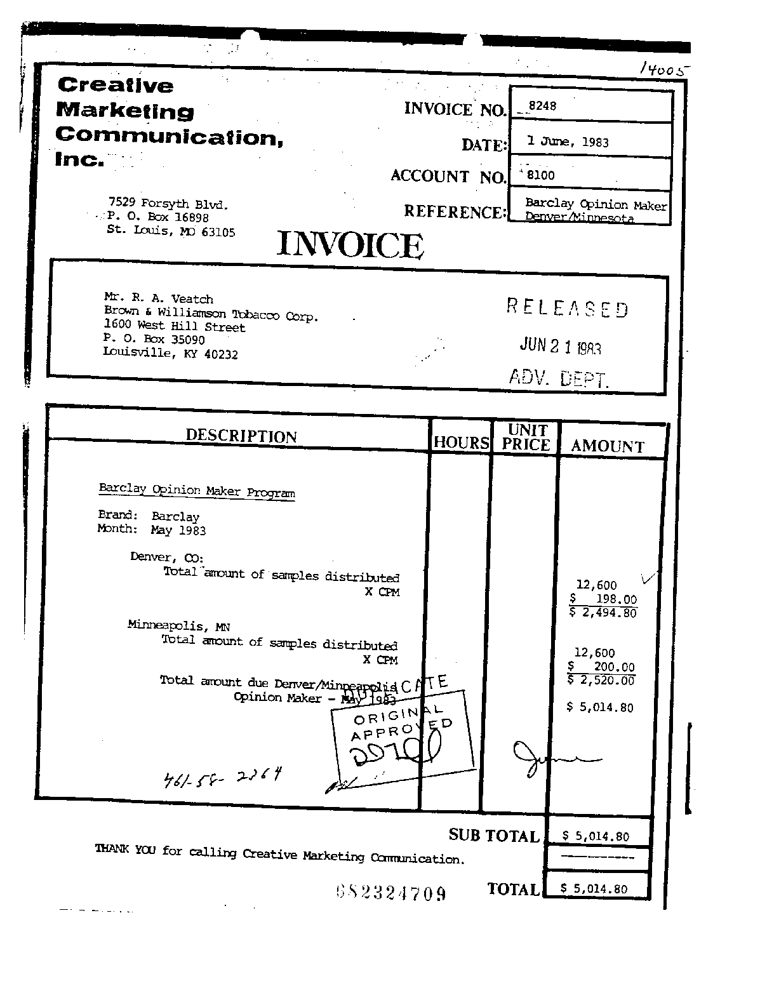

In [ ]:
train_stream = make_rvlcdip_stream("train")
val_stream = make_rvlcdip_stream("validation")
test_stream = make_rvlcdip_stream("test")

print(train_stream)
print(val_stream)
print(test_stream)

sample = next(iter(train_stream))

print("Keys:", sample.keys())
print("Label id:", sample["label"])
print("Label name:", CLASS_LABELS[int(sample["label"])])
print("Image raw type:", type(sample["image"]))
print("Image raw value keys:", sample["image"].keys() if isinstance(sample["image"], dict) else None)


def preview_image_from_stream_value(value: Any) -> Image.Image:
    """Decode one streamed image for preview only."""
    if isinstance(value, Image.Image):
        image = value

    elif isinstance(value, dict):
        if value.get("bytes") is not None:
            image = Image.open(BytesIO(value["bytes"]))
        elif value.get("path") is not None:
            image = Image.open(value["path"])
        else:
            raise ValueError("Image dict has neither bytes nor path.")

    elif isinstance(value, str):
        image = Image.open(value)

    else:
        raise TypeError(f"Unsupported image value type: {type(value)}")

    image.load()
    return image.convert("RGB")


preview_image = preview_image_from_stream_value(sample["image"])

print("Decoded preview type:", type(preview_image))
preview_image

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.Resize(256),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.CenterCrop(config.input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(config.input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [ ]:
class StreamingRVLCDIPDataset(IterableDataset):
    """Streaming PyTorch wrapper for RVL-CDIP.

    This version skips corrupted/unreadable images instead of crashing.
    """

    def __init__(
        self,
        hf_stream: Any,
        transform: transforms.Compose,
        max_examples: int | None = None,
        image_column: str = "image",
        label_column: str = "label",
    ) -> None:
        self.hf_stream = hf_stream
        self.transform = transform
        self.max_examples = max_examples
        self.image_column = image_column
        self.label_column = label_column
        self.skipped_count = 0

    def _load_image(self, value: Any) -> Image.Image:
        """Load an image from Hugging Face streaming format."""
        if isinstance(value, Image.Image):
            image = value

        elif isinstance(value, dict):
            if value.get("bytes") is not None:
                image = Image.open(BytesIO(value["bytes"]))
            elif value.get("path") is not None:
                image = Image.open(value["path"])
            else:
                raise ValueError("Image dictionary has neither bytes nor path.")

        elif isinstance(value, str):
            image = Image.open(value)

        else:
            raise TypeError(f"Unsupported image value type: {type(value)}")

        # Force PIL to actually decode the image here.
        # If it is corrupted, the error happens inside our try/except.
        image.load()
        return image.convert("RGB")

    def __iter__(self):
        yielded_count = 0

        for stream_index, example in enumerate(self.hf_stream):
            try:
                image = self._load_image(example[self.image_column])
                label = int(example[self.label_column])

                image_tensor = self.transform(image)

                yield image_tensor, label

                yielded_count += 1

                if self.max_examples is not None and yielded_count >= self.max_examples:
                    break

            except (UnidentifiedImageError, OSError, ValueError, TypeError) as error:
                self.skipped_count += 1
                print(
                    f"Skipping unreadable image at stream_index={stream_index}. "
                    f"Reason: {type(error).__name__}: {error}"
                )
                continue

In [ ]:
def build_convnext_tiny(num_classes: int = 16) -> nn.Module:
    """Build ConvNeXt Tiny with a 16-class classification head."""
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = models.convnext_tiny(weights=weights)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model


model = build_convnext_tiny(config.num_classes)
model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 125MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=16, bias=True)
)


In [ ]:
def apply_partial_unfreeze(model: nn.Module) -> None:
    """Freeze early ConvNeXt layers and unfreeze later layers plus classifier head."""

    for parameter in model.parameters():
        parameter.requires_grad = False

    # ConvNeXt features:
    # 0 stem
    # 1 stage 1
    # 2 downsample
    # 3 stage 2
    # 4 downsample
    # 5 stage 3
    # 6 downsample
    # 7 stage 4
    #
    # We keep early layers frozen and adapt later layers to document layouts.
    for layer_index in [3, 4, 5, 6, 7]:
        for parameter in model.features[layer_index].parameters():
            parameter.requires_grad = True

    for parameter in model.classifier.parameters():
        parameter.requires_grad = True


apply_partial_unfreeze(model)

trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
total_params = sum(parameter.numel() for parameter in model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable percent:    {100 * trainable_params / total_params:.2f}%")

Trainable parameters: 27,515,536
Total parameters:     27,832,432
Trainable percent:    98.86%


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.epochs,
)

use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print("AMP enabled:", use_amp)

AMP enabled: True


/tmp/ipykernel_940/65228107.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [ ]:
def format_seconds(seconds: float) -> str:
    """Format seconds as hours, minutes, seconds."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    remaining_seconds = int(seconds % 60)

    if hours > 0:
        return f"{hours}h {minutes}m {remaining_seconds}s"

    return f"{minutes}m {remaining_seconds}s"


def calculate_batch_correct_counts(
    logits: torch.Tensor,
    labels: torch.Tensor,
) -> tuple[int, int]:
    """Return top-1 and top-5 correct counts for a batch."""
    _, top5_indices = logits.topk(5, dim=1)

    top1_correct = top5_indices[:, 0].eq(labels).sum().item()
    top5_correct = top5_indices.eq(labels.view(-1, 1)).any(dim=1).sum().item()

    return int(top1_correct), int(top5_correct)

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    total_steps: int,
) -> dict[str, float]:
    """Train the model for one epoch."""
    model.train()

    running_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total_samples = 0

    progress = tqdm(loader, desc="Training", total=total_steps, leave=False)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        batch_top1, batch_top5 = calculate_batch_correct_counts(logits.detach(), labels)

        running_loss += loss.item() * batch_size
        correct_top1 += batch_top1
        correct_top5 += batch_top5
        total_samples += batch_size

        progress.set_postfix({
            "loss": f"{running_loss / total_samples:.4f}",
            "top1": f"{correct_top1 / total_samples:.4f}",
            "top5": f"{correct_top5 / total_samples:.4f}",
        })

    return {
        "loss": running_loss / total_samples,
        "top1": correct_top1 / total_samples,
        "top5": correct_top5 / total_samples,
    }

In [ ]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    total_steps: int,
    desc: str = "Evaluating",
) -> dict[str, float]:
    """Evaluate the model on a streaming dataloader."""
    model.eval()

    running_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total_samples = 0

    progress = tqdm(loader, desc=desc, total=total_steps, leave=False)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        batch_top1, batch_top5 = calculate_batch_correct_counts(logits, labels)

        running_loss += loss.item() * batch_size
        correct_top1 += batch_top1
        correct_top5 += batch_top5
        total_samples += batch_size

        progress.set_postfix({
            "loss": f"{running_loss / total_samples:.4f}",
            "top1": f"{correct_top1 / total_samples:.4f}",
            "top5": f"{correct_top5 / total_samples:.4f}",
        })

    return {
        "loss": running_loss / total_samples,
        "top1": correct_top1 / total_samples,
        "top5": correct_top5 / total_samples,
    }

In [ ]:
def save_training_checkpoint(
    checkpoint_path: Path,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: Any,
    scaler: Any,
    best_val_top1: float,
    epochs_without_improvement: int,
    history: list[dict[str, Any]],
    config: TrainConfig,
) -> None:
    """Save a full training checkpoint.

    This allows training to resume after Colab disconnects.
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_top1": best_val_top1,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "config": config.__dict__,
    }

    torch.save(checkpoint, checkpoint_path)


def load_training_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: Any,
    scaler: Any,
    device: torch.device,
) -> dict[str, Any]:
    """Load a checkpoint and restore model, optimizer, scheduler, and scaler."""
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint

In [ ]:
resume_from_checkpoint = False

latest_checkpoint_path = drive_checkpoint_dir / "latest_checkpoint.pt"
best_checkpoint_path = drive_checkpoint_dir / "best_classifier_checkpoint.pt"
best_model_path = Path(config.output_dir) / "best_classifier_state_dict.pt"

best_val_top1 = 0.0
epochs_without_improvement = 0
history = []
start_epoch = 1

if resume_from_checkpoint and latest_checkpoint_path.exists():
    print("Loading checkpoint:", latest_checkpoint_path)

    checkpoint = load_training_checkpoint(
        checkpoint_path=latest_checkpoint_path,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=device,
    )

    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_top1 = float(checkpoint["best_val_top1"])
    epochs_without_improvement = int(checkpoint["epochs_without_improvement"])
    history = checkpoint["history"]

    print("Resumed from epoch:", checkpoint["epoch"])
    print("Best validation top-1 so far:", best_val_top1)

start_time = time.time()

for epoch in range(start_epoch, config.epochs + 1):
    print(f"\nEpoch {epoch}/{config.epochs}")
    print("-" * 40)

    fresh_train_stream = make_rvlcdip_stream("train")

    train_dataset = StreamingRVLCDIPDataset(
        hf_stream=fresh_train_stream.shuffle(buffer_size=10_000, seed=SEED + epoch),
        transform=train_transform,
        max_examples=train_max_examples,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        total_steps=train_steps,
    )

    fresh_val_stream = make_rvlcdip_stream("validation")

    val_dataset = StreamingRVLCDIPDataset(
        hf_stream=fresh_val_stream,
        transform=eval_transform,
        max_examples=val_max_examples,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        total_steps=val_steps,
        desc="Validation",
    )

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_result = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_result)

    print("Train:", train_metrics)
    print("Val:  ", val_metrics)
    print("LR:   ", current_lr)

    val_top1 = float(val_metrics["top1"])
    improved = val_top1 > best_val_top1 + config.early_stopping_min_delta

    if improved:
        best_val_top1 = val_top1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)

        save_training_checkpoint(
            checkpoint_path=best_checkpoint_path,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            best_val_top1=best_val_top1,
            epochs_without_improvement=epochs_without_improvement,
            history=history,
            config=config,
        )

        print(f"New best model saved: val_top1={best_val_top1:.4f}")

    else:
        epochs_without_improvement += 1
        print(
            "No meaningful validation improvement. "
            f"Patience: {epochs_without_improvement}/{config.early_stopping_patience}"
        )

    save_training_checkpoint(
        checkpoint_path=latest_checkpoint_path,
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        best_val_top1=best_val_top1,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
        config=config,
    )

    numbered_checkpoint_path = drive_checkpoint_dir / f"checkpoint_epoch_{epoch:03d}.pt"

    save_training_checkpoint(
        checkpoint_path=numbered_checkpoint_path,
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        best_val_top1=best_val_top1,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
        config=config,
    )

    history_path = drive_checkpoint_dir / "training_history.json"

    with history_path.open("w", encoding="utf-8") as file:
        json.dump(history, file, indent=2)

    print("Saved latest checkpoint to:", latest_checkpoint_path)
    print("Saved numbered checkpoint to:", numbered_checkpoint_path)
    print("Saved history to:", history_path)

    if epochs_without_improvement >= config.early_stopping_patience:
        print("Early stopping triggered.")
        break

total_time = time.time() - start_time

print(f"\nTraining finished in {format_seconds(total_time)}")
print("Best validation top-1:", best_val_top1)
print("Best model path:", best_model_path)
print("Best checkpoint path:", best_checkpoint_path)


Epoch 1/8
----------------------------------------


Training:   0%|          | 0/704 [00:00<?, ?it/s]

/tmp/ipykernel_940/1526210706.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train: {'loss': 0.9067628820631239, 'top1': 0.7310777777777778, 'top5': 0.9372222222222222}
Val:   {'loss': 0.652947000169754, 'top1': 0.8107, 'top5': 0.9649}
LR:    9.619397662556435e-05
New best model saved: val_top1=0.8107
Saved latest checkpoint to: /content/drive/MyDrive/doc_classifier_checkpoints/latest_checkpoint.pt
Saved numbered checkpoint to: /content/drive/MyDrive/doc_classifier_checkpoints/checkpoint_epoch_001.pt
Saved history to: /content/drive/MyDrive/doc_classifier_checkpoints/training_history.json

Epoch 2/8
----------------------------------------


...

Training:   0%|          | 0/704 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train: {'loss': 0.4474048977878359, 'top1': 0.8670555555555556, 'top5': 0.9813555555555555}
Val:   {'loss': 0.5123461382389068, 'top1': 0.8485, 'top5': 0.9757}
LR:    6.91341716182545e-05
New best model saved: val_top1=0.8485
Saved latest checkpoint to: /content/drive/MyDrive/doc_classifier_checkpoints/latest_checkpoint.pt
Saved numbered checkpoint to: /content/drive/MyDrive/doc_classifier_checkpoints/checkpoint_epoch_003.pt
Saved history to: /content/drive/MyDrive/doc_classifier_checkpoints/training_history.json

Epoch 4/8
----------------------------------------


Training:   0%|          | 0/704 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
best_checkpoint_path = Path(config.drive_checkpoint_dir) / "best_classifier_checkpoint.pt"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = build_convnext_tiny(config.num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

best_val_top1 = float(checkpoint["best_val_top1"])
history = checkpoint["history"]

print("Loaded best model from Drive.")
print("Best validation top-1:", best_val_top1)
print("Best epoch:", checkpoint["epoch"])

Loaded best model from Drive.
Best validation top-1: 0.8485
Best epoch: 3


In [ ]:
fresh_test_stream = make_rvlcdip_stream("test")

test_dataset = StreamingRVLCDIPDataset(
    hf_stream=fresh_test_stream,
    transform=eval_transform,
    max_examples=test_max_examples,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_metrics = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    total_steps=test_steps,
    desc="Full Test Evaluation",
)

print("Full test metrics:")
print(test_metrics)
print("Skipped unreadable test images:", test_dataset.skipped_count)

Full Test Evaluation:   0%|          | 0/313 [00:00<?, ?it/s]

Skipping unreadable image at stream_index=33669. Reason: UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7b0b9f38ee80>
Full test metrics:
{'loss': 0.5095190305193232, 'top1': 0.8529213230330758, 'top5': 0.973374334358359}
Skipped unreadable test images: 1


In [ ]:
@torch.no_grad()
def collect_true_and_pred_labels(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    total_steps: int,
) -> tuple[list[int], list[int]]:
    """Collect true labels and predicted labels."""
    model.eval()

    all_true = []
    all_pred = []

    progress = tqdm(loader, desc="Collecting predictions", total=total_steps)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_true.extend(labels.cpu().tolist())
        all_pred.extend(preds.cpu().tolist())

    return all_true, all_pred


fresh_test_stream = make_rvlcdip_stream("test")

fresh_test_dataset = StreamingRVLCDIPDataset(
    hf_stream=fresh_test_stream,
    transform=eval_transform,
    max_examples=test_max_examples,
)

fresh_test_loader = DataLoader(
    fresh_test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=torch.cuda.is_available(),
)

true_labels, pred_labels = collect_true_and_pred_labels(
    model=model,
    loader=fresh_test_loader,
    device=device,
    total_steps=test_steps,
)

cm = confusion_matrix(true_labels, pred_labels, labels=list(range(config.num_classes)))

per_class_accuracy = {}

for class_id, class_name in label_id_to_name.items():
    total = cm[class_id].sum()
    correct = cm[class_id, class_id]
    accuracy = float(correct / total) if total > 0 else 0.0
    per_class_accuracy[class_name] = accuracy

worst_class_name = min(per_class_accuracy, key=per_class_accuracy.get)
worst_class_accuracy = per_class_accuracy[worst_class_name]

print("Per-class accuracy:")
for class_name, accuracy in per_class_accuracy.items():
    print(f"{class_name:25s} {accuracy:.4f}")

print("\nWorst class:", worst_class_name, worst_class_accuracy)

Skipping unreadable image at stream_index=33669. Reason: UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7b0bc2f7fbf0>
Per-class accuracy:
letter                    0.8409
form                      0.7366
email                     0.9297
handwritten               0.9198
advertisement             0.9014
scientific_report         0.7278
scientific_publication    0.8977
specification             0.8439
file_folder               0.9438
news_article              0.8189
budget                    0.8244
invoice                   0.8837
presentation              0.7923
questionnaire             0.7844
resume                    0.9082
memo                      0.8864

Worst class: scientific_report 0.7277822257806245


In [ ]:
classifier_dir = Path(config.artifacts_dir) / "app" / "classifier" / "models"
classifier_dir.mkdir(parents=True, exist_ok=True)

final_weights_path = classifier_dir / "classifier.pt"

torch.save(model.state_dict(), final_weights_path)

print("Saved final weights to:", final_weights_path)
print("File size MB:", final_weights_path.stat().st_size / (1024 * 1024))

Saved final weights to: /content/doc_classifier_outputs/artifacts_for_repo/app/classifier/models/classifier.pt
File size MB: 106.23645687103271


In [ ]:
def calculate_sha256(path: Path) -> str:
    """Calculate SHA-256 hash for a file."""
    sha256 = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            sha256.update(chunk)

    return sha256.hexdigest()


classifier_sha256 = calculate_sha256(final_weights_path)

print("SHA-256:")
print(classifier_sha256)

SHA-256:
b9b2a9c7247094679f5b4b8817071c6d6dd9b0103f61bc85166cff5ed912307a


In [ ]:
@torch.no_grad()
def predict_pil_image(
    model: nn.Module,
    image: Image.Image,
    device: torch.device,
    labels: list[str],
) -> dict[str, Any]:
    """Predict one PIL image and return top-1 and top-5 results."""
    model.eval()

    image = image.convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)

    logits = model(tensor)
    probabilities = torch.softmax(logits, dim=1)

    top5_scores, top5_indices = torch.topk(probabilities, k=5, dim=1)

    top5_indices_list = top5_indices[0].cpu().tolist()
    top5_scores_list = top5_scores[0].cpu().tolist()

    top5_labels = [labels[index] for index in top5_indices_list]

    return {
        "label": top5_labels[0],
        "confidence": float(top5_scores_list[0]),
        "top5_labels": top5_labels,
        "top5_scores": [float(score) for score in top5_scores_list],
    }


def load_image_from_stream_value(value: Any) -> Image.Image:
    """Load PIL image from a Hugging Face streaming image value.

    Works with decode=False, where image value is usually:
    {"bytes": ..., "path": ...}
    """
    if isinstance(value, Image.Image):
        image = value

    elif isinstance(value, dict):
        if value.get("bytes") is not None:
            image = Image.open(BytesIO(value["bytes"]))
        elif value.get("path") is not None:
            image = Image.open(value["path"])
        else:
            raise ValueError("Image dictionary has neither bytes nor path.")

    elif isinstance(value, str):
        image = Image.open(value)

    else:
        raise TypeError(f"Unsupported image value type: {type(value)}")

    # Force PIL to decode now, so corrupted images fail here
    # and can be skipped by the caller.
    image.load()

    return image.convert("RGB")

In [ ]:
@torch.no_grad()
def select_golden_from_stream(
    model: nn.Module,
    stream: Any,
    output_dir: Path,
    total_size: int = 50,
    max_scan: int = 40_000,
) -> list[dict[str, Any]]:
    """Select and save golden images from a streaming test split.

    This function:
    - scans the test stream
    - skips corrupted/unreadable images
    - selects easy examples
    - selects ambiguous examples
    - fills the rest with lower-confidence edge examples
    - saves 50 TIFF images
    - creates the expected prediction records
    """

    model.eval()
    output_dir.mkdir(parents=True, exist_ok=True)

    easy_by_class: dict[str, dict[str, Any]] = {}
    ambiguous_by_class: dict[str, dict[str, Any]] = {}
    low_confidence_pool: list[dict[str, Any]] = []

    skipped_golden_candidates = 0

    for index, example in enumerate(tqdm(stream, total=max_scan, desc="Scanning test stream")):
        if index >= max_scan:
            break

        try:
            true_id = int(example["label"])
            true_label = label_id_to_name[true_id]

            image = load_image_from_stream_value(example["image"])
            prediction = predict_pil_image(model, image, device, CLASS_LABELS)

        except (UnidentifiedImageError, OSError, ValueError, TypeError) as error:
            skipped_golden_candidates += 1
            print(
                f"Skipping unreadable golden candidate at stream_index={index}. "
                f"Reason: {type(error).__name__}: {error}"
            )
            continue

        # For the golden set, keep only correctly predicted examples.
        # This makes the golden set stable and easier to explain.
        if prediction["label"] != true_label:
            continue

        margin = prediction["top5_scores"][0] - prediction["top5_scores"][1]

        row = {
            "source_index": index,
            "true_label": true_label,
            "expected_label": prediction["label"],
            "expected_top1_confidence": prediction["confidence"],
            "top5_labels": prediction["top5_labels"],
            "top5_scores": prediction["top5_scores"],
            "margin": float(margin),
            "image": image.copy(),
        }

        # Easy example = highest confidence correct prediction per class.
        current_easy = easy_by_class.get(true_label)
        if (
            current_easy is None
            or row["expected_top1_confidence"] > current_easy["expected_top1_confidence"]
        ):
            easy_by_class[true_label] = row

        # Ambiguous example = smallest top-1/top-2 margin per class.
        current_ambiguous = ambiguous_by_class.get(true_label)
        if current_ambiguous is None or row["margin"] < current_ambiguous["margin"]:
            ambiguous_by_class[true_label] = row

        # Low-confidence pool = extra edge cases used to fill up to 50.
        low_confidence_pool.append(row)
        low_confidence_pool = sorted(
            low_confidence_pool,
            key=lambda item: item["expected_top1_confidence"],
        )[:120]

    selected = []
    used_source_indices = set()

    # Add 1 easy + 1 ambiguous example for each class.
    for class_name in CLASS_LABELS:
        for candidate, difficulty in [
            (easy_by_class.get(class_name), "easy"),
            (ambiguous_by_class.get(class_name), "ambiguous"),
        ]:
            if candidate is None:
                print(f"WARNING: missing {difficulty} candidate for {class_name}")
                continue

            if candidate["source_index"] not in used_source_indices:
                candidate = dict(candidate)
                candidate["difficulty"] = difficulty
                selected.append(candidate)
                used_source_indices.add(candidate["source_index"])

    # Fill remaining slots with low-confidence edge cases.
    for candidate in low_confidence_pool:
        if len(selected) >= total_size:
            break

        if candidate["source_index"] not in used_source_indices:
            candidate = dict(candidate)
            candidate["difficulty"] = "edge_low_confidence"
            selected.append(candidate)
            used_source_indices.add(candidate["source_index"])

    selected = selected[:total_size]

    if len(selected) < total_size:
        raise RuntimeError(
            f"Only selected {len(selected)} golden images, expected {total_size}."
        )

    golden_expected = []

    for image_number, row in enumerate(selected, start=1):
        filename = f"{image_number:04d}.tif"
        image_path = output_dir / filename

        # Save the selected image as TIFF.
        row["image"].save(image_path, format="TIFF")

        # Re-open the saved TIFF and regenerate prediction from the exact saved file.
        # This makes golden_expected.json match the exact artifact in golden_images/.
        saved_image = Image.open(image_path).convert("RGB")
        saved_prediction = predict_pil_image(model, saved_image, device, CLASS_LABELS)

        golden_expected.append({
            "filename": filename,
            "expected_label": saved_prediction["label"],
            "expected_top1_confidence": float(saved_prediction["confidence"]),
            "true_label": row["true_label"],
            "source_split": "test",
            "source_index": int(row["source_index"]),
            "difficulty": row["difficulty"],
            "top5_labels": saved_prediction["top5_labels"],
            "top5_scores": [float(score) for score in saved_prediction["top5_scores"]],
        })

    print("Skipped unreadable golden candidates:", skipped_golden_candidates)

    return golden_expected

In [ ]:
golden_images_dir = (
    Path(config.artifacts_dir)
    / "app"
    / "classifier"
    / "eval"
    / "golden_images"
)

golden_expected_path = (
    Path(config.artifacts_dir)
    / "app"
    / "classifier"
    / "eval"
    / "golden_expected.json"
)

fresh_golden_test_stream = make_rvlcdip_stream("test")

golden_expected = select_golden_from_stream(
    model=model,
    stream=fresh_golden_test_stream,
    output_dir=golden_images_dir,
    total_size=50,
    max_scan=TEST_SIZE if not config.fast_dev_run else config.fast_test_samples,
)

golden_expected_path.parent.mkdir(parents=True, exist_ok=True)

with golden_expected_path.open("w", encoding="utf-8") as file:
    json.dump(golden_expected, file, indent=2)

print("Saved golden images to:", golden_images_dir)
print("Saved golden expected to:", golden_expected_path)
print("Golden count:", len(golden_expected))

class_counts = {}
for item in golden_expected:
    class_counts[item["true_label"]] = class_counts.get(item["true_label"], 0) + 1

print("Golden class counts:")
for class_name in CLASS_LABELS:
    print(f"{class_name:25s} {class_counts.get(class_name, 0)}")

print(json.dumps(golden_expected[:2], indent=2))

Scanning test stream:   0%|          | 0/40000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Skipping unreadable golden candidate at stream_index=33669. Reason: UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7b0b9e0d3380>
Skipped unreadable golden candidates: 1
Saved golden images to: /content/doc_classifier_outputs/artifacts_for_repo/app/classifier/eval/golden_images
Saved golden expected to: /content/doc_classifier_outputs/artifacts_for_repo/app/classifier/eval/golden_expected.json
Golden count: 50
Golden class counts:
letter                    2
form                      4
email                     2
handwritten               2
advertisement             2
scientific_report         4
scientific_publication    3
specification             2
file_folder               7
news_article              2
budget                    4
invoice                   2
presentation              4
questionnaire             4
resume                    3
memo                      3
[
  {
    "filename": "0001.tif",
    "expected_label": "letter",
    "expected_top1_conf

In [ ]:
golden_correct = sum(
    1 for item in golden_expected
    if item["expected_label"] == item["true_label"]
)

golden_top1 = golden_correct / len(golden_expected)

print("Golden true-label top-1:", golden_top1)

Golden true-label top-1: 1.0


In [ ]:
# Cell 29 — Create model_card.json

test_skipped_unreadable_images = int(getattr(test_dataset, "skipped_count", 0))
test_evaluated_images = int(test_max_examples - test_skipped_unreadable_images)

golden_class_counts = {}
for item in golden_expected:
    golden_class_counts[item["true_label"]] = golden_class_counts.get(item["true_label"], 0) + 1

model_passes_required_top1 = float(test_metrics["top1"]) >= float(config.min_test_top1)

model_card = {
    "project": "document-classifier-as-authenticated-service",

    # Top-level fields used by app/classifier/model.py later
    "sha256": classifier_sha256,
    "required_test_top1": float(config.min_test_top1),
    "test_top1": float(test_metrics["top1"]),
    "test_top5": float(test_metrics["top5"]),
    "golden_top1": float(golden_top1),
    "passes_required_test_top1": bool(model_passes_required_top1),

    "backbone": config.backbone,
    "torchvision_weights_enum": config.weights_enum,
    "freeze_policy": config.freeze_policy,

    "dataset": {
        "name": "RVL-CDIP",
        "source": "adamharley.com/rvl-cdip",
        "task": "visual_document_layout_classification",
        "num_classes": config.num_classes,
        "classes": CLASS_LABELS,
        "note": "No OCR used. The model classifies visual document layout only.",
    },

    "model": {
        "backbone": config.backbone,
        "torchvision_weights_enum": config.weights_enum,
        "freeze_policy": config.freeze_policy,
        "input_size": config.input_size,
        "input_channels": 3,
        "input_mode": "grayscale_or_tiff_document_converted_to_RGB",
    },

    "training": {
        "optimizer": "AdamW",
        "learning_rate": float(config.learning_rate),
        "weight_decay": float(config.weight_decay),
        "scheduler": "CosineAnnealingLR",
        "epochs_max": int(config.epochs),
        "epochs_completed": int(len(history)),
        "best_epoch": int(checkpoint["epoch"]) if "checkpoint" in globals() else None,
        "batch_size": int(config.batch_size),
        "num_workers": int(config.num_workers),

        "train_examples_used": int(train_max_examples),
        "validation_examples_used": int(val_max_examples),
        "test_examples_expected": int(test_max_examples),

        "early_stopping": {
            "enabled": True,
            "patience": int(config.early_stopping_patience),
            "min_delta": float(config.early_stopping_min_delta),
            "metric": "validation_top1",
        },

        "seed": int(SEED),

        "augmentations": [
            "Resize(256)",
            "RandomRotation(5)",
            "ColorJitter(brightness=0.15, contrast=0.15)",
            "CenterCrop(224)",
            "Normalize(ImageNet mean/std)",
        ],

        "streaming": {
            "used": True,
            "reason": "RVL-CDIP is large, so training and evaluation used Hugging Face streaming mode to avoid Colab disk-space issues.",
            "decode_false_used": True,
            "decode_false_reason": "Images were decoded manually so corrupted TIFF files could be skipped safely.",
        },
    },

    "metrics": {
        "validation_best_top1": float(best_val_top1),

        "test_top1": float(test_metrics["top1"]),
        "test_top5": float(test_metrics["top5"]),
        "test_loss": float(test_metrics["loss"]),

        "required_test_top1": float(config.min_test_top1),
        "passes_required_test_top1": bool(model_passes_required_top1),

        "test_examples_expected": int(test_max_examples),
        "test_evaluated_images": int(test_evaluated_images),
        "test_skipped_unreadable_images": int(test_skipped_unreadable_images),

        "golden_top1_against_true_labels": float(golden_top1),
        "golden_images_count": int(len(golden_expected)),
        "golden_class_counts": {
            class_name: int(golden_class_counts.get(class_name, 0))
            for class_name in CLASS_LABELS
        },

        "per_class_accuracy": {
            class_name: float(accuracy)
            for class_name, accuracy in per_class_accuracy.items()
        },

        "worst_class": {
            "name": worst_class_name,
            "accuracy": float(worst_class_accuracy),
        },
    },

    "golden_set": {
        "images_dir": "app/classifier/eval/golden_images",
        "expected_file": "app/classifier/eval/golden_expected.json",
        "count": int(len(golden_expected)),
        "selection_policy": [
            "Only correctly predicted test examples were selected.",
            "At least two examples were selected per class when available.",
            "The set includes easy, ambiguous, and lower-confidence edge examples.",
            "Expected labels and confidence scores were generated from the exact saved TIFF files.",
        ],
        "confidence_tolerance_for_ci": 1e-6,
    },

    "artifact": {
        "filename": "classifier.pt",
        "path": "app/classifier/models/classifier.pt",
        "sha256": classifier_sha256,
        "size_mb": float(final_weights_path.stat().st_size / (1024 * 1024)),
        "format": "torch_state_dict",
    },

    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": __import__("torchvision").__version__,
        "datasets": datasets.__version__,
        "cuda_available": bool(torch.cuda.is_available()),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    },

    "notes": [
        "The configured required test top-1 threshold is 0.80.",
        "This model achieved approximately 0.8529 test top-1 and passes the configured threshold.",
        "One unreadable/corrupted TIFF image was skipped during full test evaluation.",
        "The full RVL-CDIP dataset is not included in the repository.",
        "Only classifier.pt, model_card.json, golden_images, and golden_expected.json are exported to the project repo.",
    ],
}

model_card_path = classifier_dir / "model_card.json"

with model_card_path.open("w", encoding="utf-8") as file:
    json.dump(model_card, file, indent=2)

print("Saved model card:", model_card_path)
print("Passes required test top-1:", model_card["passes_required_test_top1"])
print("Required test top-1:", model_card["required_test_top1"])
print("Actual test top-1:", model_card["test_top1"])
print("Test evaluated images:", model_card["metrics"]["test_evaluated_images"])
print("Skipped unreadable test images:", model_card["metrics"]["test_skipped_unreadable_images"])

print(json.dumps(model_card, indent=2)[:3000])

Saved model card: /content/doc_classifier_outputs/artifacts_for_repo/app/classifier/models/model_card.json
Passes required test top-1: True
Required test top-1: 0.8
Actual test top-1: 0.8529213230330758
Test evaluated images: 39999
Skipped unreadable test images: 1
{
  "project": "document-classifier-as-authenticated-service",
  "sha256": "b9b2a9c7247094679f5b4b8817071c6d6dd9b0103f61bc85166cff5ed912307a",
  "required_test_top1": 0.8,
  "test_top1": 0.8529213230330758,
  "test_top5": 0.973374334358359,
  "golden_top1": 1.0,
  "passes_required_test_top1": true,
  "backbone": "convnext_tiny",
  "torchvision_weights_enum": "ConvNeXt_Tiny_Weights.IMAGENET1K_V1",
  "freeze_policy": "partial_unfreeze",
  "dataset": {
    "name": "RVL-CDIP",
    "source": "adamharley.com/rvl-cdip",
    "task": "visual_document_layout_classification",
    "num_classes": 16,
    "classes": [
      "letter",
      "form",
      "email",
      "handwritten",
      "advertisement",
      "scientific_report",
      

In [ ]:
with model_card_path.open("r", encoding="utf-8") as file:
    saved_model_card = json.load(file)

print("Loaded saved model card successfully.")
print("Top-level keys:", saved_model_card.keys())
print("Worst class:", saved_model_card["metrics"]["worst_class"])
print("Golden class counts:", saved_model_card["metrics"]["golden_class_counts"])

Loaded saved model card successfully.
Top-level keys: dict_keys(['project', 'sha256', 'required_test_top1', 'test_top1', 'test_top5', 'golden_top1', 'passes_required_test_top1', 'backbone', 'torchvision_weights_enum', 'freeze_policy', 'dataset', 'model', 'training', 'metrics', 'golden_set', 'artifact', 'environment', 'notes'])
Worst class: {'name': 'scientific_report', 'accuracy': 0.7277822257806245}
Golden class counts: {'letter': 2, 'form': 4, 'email': 2, 'handwritten': 2, 'advertisement': 2, 'scientific_report': 4, 'scientific_publication': 3, 'specification': 2, 'file_folder': 7, 'news_article': 2, 'budget': 4, 'invoice': 2, 'presentation': 4, 'questionnaire': 4, 'resume': 3, 'memo': 3}


In [ ]:
history_path = Path(config.output_dir) / "training_history.json"

with history_path.open("w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

print("Saved training history:", history_path)

Saved training history: /content/doc_classifier_outputs/training_history.json


In [ ]:
reload_model = models.convnext_tiny(weights=None, num_classes=config.num_classes)
state_dict = torch.load(final_weights_path, map_location="cpu")
reload_model.load_state_dict(state_dict)
reload_model = reload_model.to(device)
reload_model.eval()

print("Reloaded classifier.pt successfully.")

Reloaded classifier.pt successfully.


In [ ]:
@torch.no_grad()
def replay_golden_set(
    model: nn.Module,
    golden_images_dir: Path,
    golden_expected_path: Path,
    tolerance: float = 1e-6,
) -> None:
    """Replay golden set and fail if predictions differ."""
    with golden_expected_path.open("r", encoding="utf-8") as file:
        expected_items = json.load(file)

    failures = []

    for item in tqdm(expected_items, desc="Golden replay"):
        image_path = golden_images_dir / item["filename"]
        image = Image.open(image_path).convert("RGB")

        result = predict_pil_image(model, image, device, CLASS_LABELS)

        label_ok = result["label"] == item["expected_label"]
        confidence_diff = abs(result["confidence"] - item["expected_top1_confidence"])
        confidence_ok = confidence_diff < tolerance

        if not label_ok or not confidence_ok:
            failures.append({
                "filename": item["filename"],
                "expected_label": item["expected_label"],
                "actual_label": result["label"],
                "expected_confidence": item["expected_top1_confidence"],
                "actual_confidence": result["confidence"],
                "confidence_diff": confidence_diff,
            })

    if failures:
        print(json.dumps(failures[:5], indent=2))
        raise AssertionError(f"Golden replay failed on {len(failures)} images.")

    print("Golden replay passed.")


replay_golden_set(
    model=reload_model,
    golden_images_dir=golden_images_dir,
    golden_expected_path=golden_expected_path,
)

Golden replay:   0%|          | 0/50 [00:00<?, ?it/s]

Golden replay passed.


In [ ]:
@torch.no_grad()
def measure_golden_latency(
    model: nn.Module,
    golden_images_dir: Path,
    golden_expected_path: Path,
    device: torch.device,
) -> dict[str, float]:
    """Measure inference latency on golden images."""
    with golden_expected_path.open("r", encoding="utf-8") as file:
        expected_items = json.load(file)

    latencies_ms = []
    model.eval()

    for item in tqdm(expected_items, desc="Timing golden inference"):
        image_path = golden_images_dir / item["filename"]
        image = Image.open(image_path).convert("RGB")

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        _ = predict_pil_image(model, image, device, CLASS_LABELS)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()
        latencies_ms.append((end - start) * 1000)

    return {
        "p50_ms": float(np.percentile(latencies_ms, 50)),
        "p95_ms": float(np.percentile(latencies_ms, 95)),
        "p99_ms": float(np.percentile(latencies_ms, 99)),
        "mean_ms": float(np.mean(latencies_ms)),
    }


latency_metrics = measure_golden_latency(
    model=reload_model,
    golden_images_dir=golden_images_dir,
    golden_expected_path=golden_expected_path,
    device=device,
)

print(latency_metrics)

Timing golden inference:   0%|          | 0/50 [00:00<?, ?it/s]

{'p50_ms': 40.314839001439395, 'p95_ms': 57.5812784487425, 'p99_ms': 67.57137154942028, 'mean_ms': 37.9030886801047}


In [ ]:
model_card["latency_colab_estimate"] = latency_metrics

with model_card_path.open("w", encoding="utf-8") as file:
    json.dump(model_card, file, indent=2)

print("Updated model_card.json with latency estimate.")

Updated model_card.json with latency estimate.


In [ ]:
export_zip_path = Path(config.output_dir) / "member_a_artifacts_for_repo.zip"

if export_zip_path.exists():
    export_zip_path.unlink()

shutil.make_archive(
    base_name=str(export_zip_path).replace(".zip", ""),
    format="zip",
    root_dir=Path(config.artifacts_dir),
)

print("Created:", export_zip_path)
print("Copy these files into your repo:")
print("""
app/classifier/models/classifier.pt
app/classifier/models/model_card.json
app/classifier/eval/golden_images/
app/classifier/eval/golden_expected.json
""")

Created: /content/doc_classifier_outputs/member_a_artifacts_for_repo.zip
Copy these files into your repo:

app/classifier/models/classifier.pt
app/classifier/models/model_card.json
app/classifier/eval/golden_images/
app/classifier/eval/golden_expected.json

